Mean Rating: 2.87
Median Rating: 3.0
Mode Rating: 1
Range of Purchase Amount: 19.97
IQR of Purchase Amount: 10.192499999999999
Variance of Likes: 822.85
Standard Deviation of Likes: 28.69
Correlation: 0.84


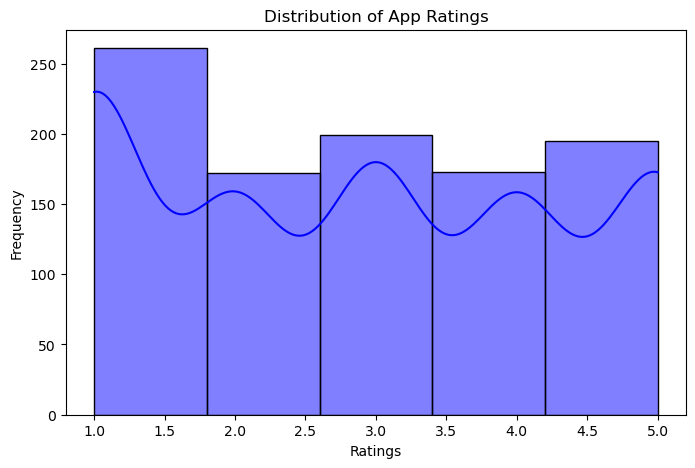

p-value: 0.7868
No significant difference in ratings between Instagram and WhatsApp.


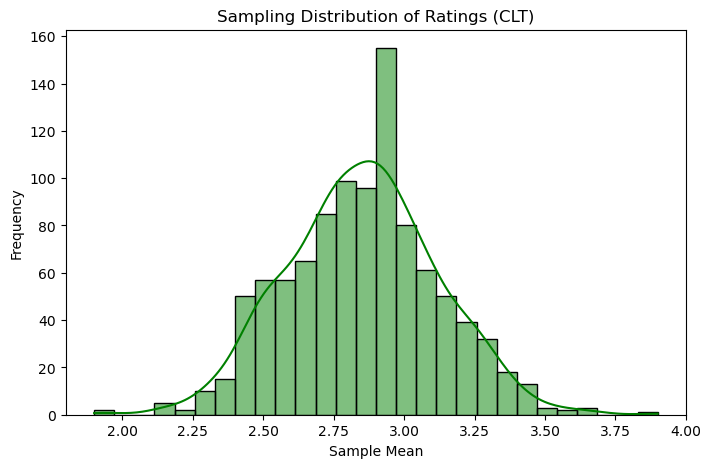

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

# Load the dataset
df = pd.read_csv("Apple_Store_Reviews.csv")

# 1. Central Tendency
ratings = df['Rating']
mean_rating = ratings.mean()
median_rating = ratings.median()
mode_rating = ratings.mode().iloc[0]

print(f"Mean Rating: {mean_rating:.2f}")
print(f"Median Rating: {median_rating}")
print(f"Mode Rating: {mode_rating}")

# 2. Purchase Amount Spread
purchase = df['Purchase_Amount']
purchase_range = purchase.max() - purchase.min()
Q1 = purchase.quantile(0.25)
Q3 = purchase.quantile(0.75)
IQR = Q3 - Q1

print(f"Range of Purchase Amount: {purchase_range}")
print(f"IQR of Purchase Amount: {IQR}")

# 3. Likes Variability
likes = df['Likes']
variance = likes.var()
std_dev = likes.std()

print(f"Variance of Likes: {variance:.2f}")
print(f"Standard Deviation of Likes: {std_dev:.2f}")

# 4. Correlation between Likes and Ratings
correlation = df[['Likes', 'Rating']].corr().iloc[0, 1]
print(f"Correlation: {correlation:.2f}")

# 5. Distribution of Ratings
plt.figure(figsize=(8, 5))
sns.histplot(df['Rating'], kde=True, bins=5, color='blue')
plt.title('Distribution of App Ratings')
plt.xlabel('Ratings')
plt.ylabel('Frequency')
plt.show()

# 6. Hypothesis Testing: Instagram vs WhatsApp Ratings
instagram_ratings = df[df['App_Name'] == 'Instagram']['Rating']
whatsapp_ratings = df[df['App_Name'] == 'WhatsApp']['Rating']

t_stat, p_value = ttest_ind(instagram_ratings, whatsapp_ratings, equal_var=False, alternative='greater')

print(f"p-value: {p_value:.4f}")
if p_value < 0.05:
    print("Instagram’s ratings are significantly higher than WhatsApp’s.")
else:
    print("No significant difference in ratings between Instagram and WhatsApp.")

# 7. Central Limit Theorem (Sampling Distribution of Ratings)
sample_means = [df['Rating'].sample(n=30, replace=True).mean() for _ in range(1000)]

plt.figure(figsize=(8, 5))
sns.histplot(sample_means, kde=True, color='green')
plt.title("Sampling Distribution of Ratings (CLT)")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.show()


https://github.com/Mohammad-Suhail-Alam/Apple-Store-Review-Analysis